In [2]:
import os, glob

import cytoflow as flow
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from flow_analysis_tools import flow_violin
from utils.color_palettes import *
from utils import CONSTRUCT_NAME_DICT, GUIDE_NAME_DICT

from rclone_tools import NodeExperimentsDirectory

## Notebook and Experiment Setup

In [1]:
DRIVE_RELPATH = "ARS_Working/Experiments/4_phHSC_Testing/260914_phHSCc12R1_Test/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_KD_check"
DATA_DIR = "/data_gilbert3/asathler/hsiung-box"
PROXY = "http://169.230.134.132:3128"

In [3]:
Experiment = NodeExperimentsDirectory(
    drive="hsiung", proxy=PROXY, output_dirname="out",
    source_relpath=DRIVE_RELPATH, node_mountpath=DATA_DIR,
)

In [4]:
Experiment.stage()

In [5]:
%matplotlib widget
matplotlib.rc('figure', dpi = 160)
plt.style.use('ggplot')

In [6]:
FCS_FILES = sorted(glob.glob(os.path.join(Experiment.dest_dirpath, "*.fcs")))
FCS_NAMES = [os.path.splitext(os.path.basename(fcs))[0] for fcs in FCS_FILES]
YLIMITS = (0, 7)
GATE_INFO = {}
BLUE_CHANNEL_NAME, BLUE_CHANNEL_TAG = "Construct", "mTagBFP2"
GREEN_CHANNEL_NAME, GREEN_CHANNEL_TAG = "Guide", "eGFP"
RED_CHANNEL_NAME, RED_CHANNEL_TAG = "CD55", "APC"
YELLOW_CHANNEL_NAME, YELLOW_CHANNEL_TAG = "CD81", "PE"
FOCUS_CHANNEL = "YL1-A"
print('\n'.join([f"'{x}'" for x in FCS_FILES]))
if isinstance(Experiment, NodeExperimentsDirectory):
    for x in FCS_FILES: Experiment.logger.info(x)

'/data_gilbert3/asathler/hsiung-box/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_KD_check/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_NT_155.fcs'
'/data_gilbert3/asathler/hsiung-box/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_KD_check/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_NT_20.fcs'
'/data_gilbert3/asathler/hsiung-box/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_KD_check/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_NT_5.fcs'
'/data_gilbert3/asathler/hsiung-box/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_KD_check/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_NT_60.fcs'
'/data_gilbert3/asathler/hsiung-box/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_KD_check/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_T_155.fcs'
'/data_gilbert3/asathler/hsiung-box/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_KD_check/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_T_20.fcs'
'/data_gilbert3/asathler/hsiung-box/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_KD_check/260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_

## Import Setup
Expects file names to have paired identity.

Each construct (e.g. LX2, Cas9, Cas12, pARS001, pARS002) should have 1 or 2 corresponding "guides" (or downstream conditions) assigned to them. So:
- **_LX2_**: Stained & Unstained
- **_Cas9_**: sgNT and sgTargeting
- ...

In [7]:
CONSTRUCT_NAME_N_UNDERSCORE = -2

# def get_construct_name(name) -> None | str:
#     this_name = name.split("_")[-CONSTRUCT_NAME_N_UNDERSCORE]
#     if this_name in construct_names.keys():
#         return construct_names[this_name]
#     return None

# def get_guide_name(name) -> None | str:
#     for this_key in guide_names.keys():
#         if this_key in name: 
#             return guide_names[this_key]
#     else:
#         return None

def get_construct_name(name):
    spot = name.split("_")[-3]
    try:
        return CONSTRUCT_NAME_DICT[spot]
    except KeyError:
        return spot

def get_treatment_name(name):
    spot = name.split("_")[-2]
    try:
        return GUIDE_NAME_DICT[spot]
    except KeyError:
        return spot

def get_guide_name(name):
    spot = name.split("_")[-1]
    try:
        return GUIDE_NAME_DICT[spot]
    except KeyError:
        return spot

In [8]:
CONSTRUCT_NAMES = [get_construct_name(fcs_file) for fcs_file in FCS_NAMES]
TREATMENT_NAMES = [get_treatment_name(fcs_file) for fcs_file in FCS_NAMES]
GUIDE_NAMES = [get_guide_name(fcs_file) for fcs_file in FCS_NAMES]
max_fcs_len = max([len(x) for x in FCS_NAMES]) + 5
for fcs, const, treatment, guide in zip(FCS_NAMES, CONSTRUCT_NAMES, TREATMENT_NAMES, GUIDE_NAMES):
    print_str = f"{fcs + ''.join([' '] * (max_fcs_len - len(fcs)))}{str(const):<20}{str(treatment):<20}{str(guide):<20}"
    print(print_str)
    # if isinstance(Experiment, NodeExperimentsDirectory):
    #     Experiment.logger.info(print_str)

import_op = flow.ImportOp(
    conditions = {
        "Construct": "category",
        "Treatment": "category",
        "Guide": "category"
    },
    tubes = [flow.Tube(file=fcs_file, conditions={
        "Construct": get_construct_name(fcs_name),
        "Treatment": get_treatment_name(fcs_name),
        "Guide": get_guide_name(fcs_name)
    }) for fcs_file, fcs_name in zip(FCS_FILES, FCS_NAMES)],
    # channels = channel_names
)

try:
    ex = import_op.apply()
except ValueError as e:
    error_text = str(e)
    if error_text == "Categorical categories cannot be null":
        raise Exception(
            "Functions 'get_construct_name' or 'get_guide_type' likely are turning None or NoneType." + \
            "\n\t   This is typically because a construct or guide name case isn't properly handled."
        )
    else:
        raise e

260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_NT_155         pARS1               NT                  155                 
260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_NT_20          pARS1               NT                  20                  
260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_NT_5           pARS1               NT                  5                   
260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_NT_60          pARS1               NT                  60                  
260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_T_155          pARS1               T                   155                 
260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_T_20           pARS1               T                   20                  
260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_T_5            pARS1               T                   5                   
260928_phHSCc12R1_v2d10-BFP_v1d6-GFP_Experiment_pARS1_T_60           pARS1               T

## Select Cells

In [9]:
%matplotlib widget

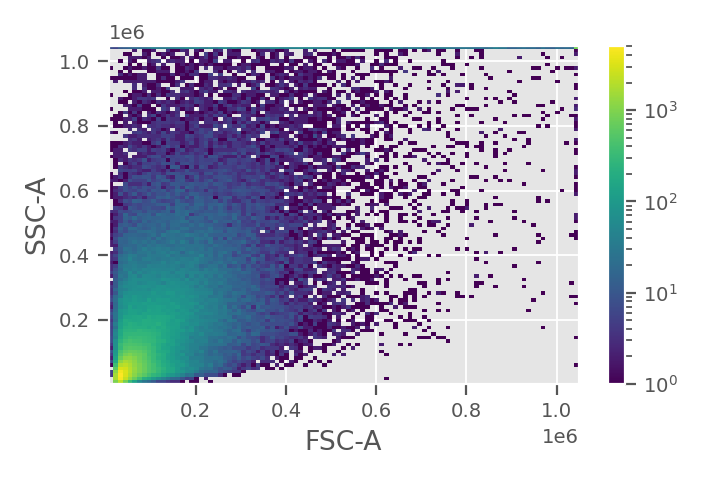

In [10]:
single_gate = flow.PolygonOp(
    name="Single_Cell",
    xchannel="FSC-A",
    ychannel="SSC-A"
)

single_gate.default_view(
    density = True,
    huescale = "log",
    interactive = True
).plot(ex, gridsize = 100)

In [11]:
plt.savefig(Experiment.output_dirpath / "single_cell_select.png")

In [12]:
GATE_INFO["single_cell"] = np.array(single_gate.vertices)

In [13]:
ex = single_gate.apply(ex)
plt.close()

## Gating

### Gating Template
Use the template below for help with gating

```
quad_gate = flow.QuadOp(
    name="",
    xchannel="",
    ychannel="",
)
single_gate = flow.PolygonOp(
    name="",
    xchannel="",
    ychannel="",
    yscale="logicle"
)
___gate = flow.PolygonOp(name="") # placeholder variable
___gate.default_view(
    density = True,
    huescale = "log",
    interactive = True,
    subset = "Single_Cell == True"
) #.plot(ex_single, gridsize=100)
ex_single_gated = ___gate.apply(ex_single)
plt.close()
```

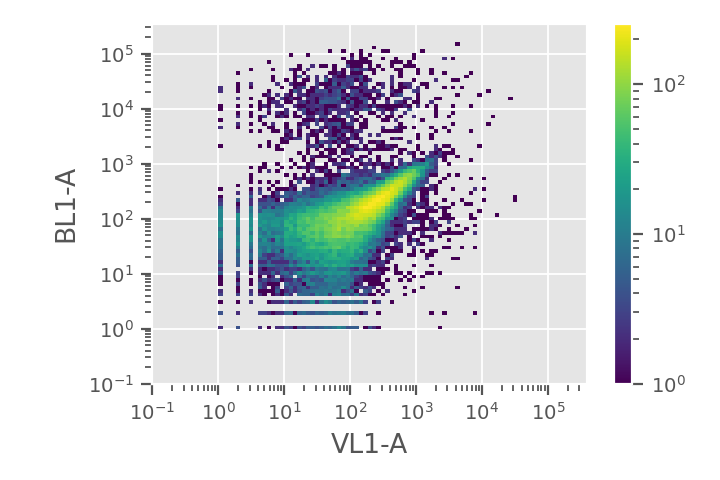

In [14]:
quad_gate = flow.QuadOp(
    name="d_pos",
    xchannel="VL1-A",
    ychannel="BL1-A",
    # xscale="logicle",
    # yscale="logicle"
)

quad_gate.default_view(
    density = True,
    huescale = "log",
    interactive = True,
    subset = "Single_Cell == True",
    xscale="log", yscale="log"
).plot(ex, gridsize=100)

In [15]:
plt.savefig(Experiment.output_dirpath / "quad_gate.png")

In [16]:
GATE_INFO["quad_gate"] = {
    "x": quad_gate.xthreshold,
    "y": quad_gate.ythreshold
}

In [17]:
ex = quad_gate.apply(ex)
plt.close()

In [18]:
if isinstance(Experiment, NodeExperimentsDirectory):
    ex.data.to_csv(os.path.join(Experiment.output_dirpath, "processed_data.csv"))

plot_data = ex.data[ex.data["Single_Cell"]==True]

# The following lines are to prevent NANs being fed into log y axes
# They may not be necessary with newer versions of Cytoflow (>1.2.2)
num_cols = plot_data.select_dtypes(include='number').columns
plot_data[num_cols] = plot_data[num_cols].replace(0, 1)

order = ['dCas9-ZIM3', 'H3t-D3L-dCas9', 'H3t-D3L-dCas9-KOX1', 'H3t-KOX1-D3L-dCas9']


channel_labels = {
    f"{BLUE_CHANNEL_NAME} ({BLUE_CHANNEL_TAG})": "VL1-A",
    f"{GREEN_CHANNEL_NAME} ({GREEN_CHANNEL_TAG})": "BL1-A",
    f"{RED_CHANNEL_NAME} ({RED_CHANNEL_TAG})": "RL1-A",
    f"{YELLOW_CHANNEL_NAME} ({YELLOW_CHANNEL_TAG})": "YL1-A"
}

channel_cmaps = {
    f"{BLUE_CHANNEL_NAME} ({BLUE_CHANNEL_TAG})": black_blue_pastel_palette,
    f"{GREEN_CHANNEL_NAME} ({GREEN_CHANNEL_TAG})": black_green_pastel_palette,
    f"{RED_CHANNEL_NAME} ({RED_CHANNEL_TAG})": black_red_pastel_palette,
    f"{YELLOW_CHANNEL_NAME} ({YELLOW_CHANNEL_TAG})": black_yellow_pastel_palette
}

FOCUS_CHANNEL_LABEL = list(channel_labels.keys())[list(channel_labels.values()).index(FOCUS_CHANNEL)]

/tmp/ipykernel_299182/722206409.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


## Graphing

In [19]:
%matplotlib inline

In [ ]:
for cas12_construct, cas12_name in zip(["pCH45", "pARS002"], ["multiAsCas12a-KOX1", "multiAsCas12a-ZIM3"]):
    for fluor, flow_channel in channel_labels.items():
        # See: https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_hist.html#id1
        fig, axs = plt.subplot_mosaic(
            [
                ["Cas9", "Cas12"]
            ],
            figsize=(9,4),
            width_ratios=(2,5),
            sharey=True,
            gridspec_kw={
                "wspace": 0.025,
                "hspace": 0,
            },
        )

        # flow_violin(
        #     data=plot_data.loc[(plot_data["Construct"] == "LX2")],
        #     x="Treatment",
        #     y=flow_channel,
        #     hue="Guide",
        #     palette=channel_cmaps[fluor],
        #     split=True,
        #     log_y_axis=True,
        #     # hue_order=["Ab-", "Ab+"],
        #     # order=["LX2"],
        #     ylabel=fluor,
        #     xlabel="",
        #     density_norm='width',
        #     ylim=YLIMITS,
        #     ax=axs['Mock']
        # )

        flow_violin(
            data=plot_data.loc[(plot_data["Construct"] == "pARS001")],
            x="Treatment",
            y=flow_channel,
            hue="Guide",
            palette=channel_cmaps[fluor],
            order=plot_data.loc[(plot_data["Construct"] == "pARS001"),"Treatment"].unique()[::-1],
            split=True,
            log_y_axis=True,
            xlabel="dCas9-ZIM3",
            ylabel=fluor,
            hue_order=plot_data.loc[(plot_data["Construct"] == "pARS001"),"Guide"].unique()[::-1],
            # legend_labels=["NT", "Col1a1"],
            ylim=YLIMITS,
            density_norm='width',
            ax=axs['Cas9'],
            # legend=False
        )

        flow_violin(
            data=plot_data.loc[plot_data["Construct"].isin([cas12_construct])],
            x="Treatment",
            y=flow_channel,
            hue="Guide",
            palette=channel_cmaps[fluor],
            order=plot_data.loc[plot_data["Construct"].isin([cas12_construct]), "Treatment"].unique(),
            split=True,
            log_y_axis=True,
            hue_order=plot_data.loc[plot_data["Construct"].isin([cas12_construct]), "Guide"].unique(),
            xlabel=f"{cas12_construct} ({cas12_name})",
            ylabel="",
            ylim=YLIMITS,
            density_norm='width',
            ax=axs['Cas12']
        )

        axs['Cas9'].get_legend().remove()
        axs['Cas12'].legend(ncol=2, title="Guide", loc="upper left")
        fig.suptitle(f"Cas9 vs. {cas12_name}")
        fig.subplots_adjust()
        if isinstance(Experiment, NodeExperimentsDirectory):
            plt.savefig(os.path.join(Experiment.output_dirpath, f"{cas12_construct}_{fluor}.png"))

In [ ]:
plot_data = plot_data.loc[(plot_data["d_pos"] == "d_pos_2")]
for cas12_construct, cas12_name in zip(["pCH45", "pARS002"], ["multiAsCas12a-KOX1", "multiAsCas12a-ZIM3"]):        
    # See: https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_hist.html#id1
    fig, axs = plt.subplot_mosaic(
        [
            ["Cas9", "Cas12"]
        ],
        figsize=(8,4),
        width_ratios=(1,4),
        sharey=True,
        gridspec_kw={
            "wspace": 0.025,
            "hspace": 0,
        },
    )

    flow_violin(
        data=plot_data.loc[(plot_data["Construct"] == "pARS001")],
        x="Treatment",
        y=FOCUS_CHANNEL,
        hue="Guide",
        palette=channel_cmaps[FOCUS_CHANNEL_LABEL],
        order=plot_data.loc[(plot_data["Construct"] == "pARS001"),"Treatment"].unique()[::-1],
        split=True,
        log_y_axis=True,
        xlabel="dCas9-ZIM3",
        ylabel=FOCUS_CHANNEL_LABEL,
        hue_order=plot_data.loc[(plot_data["Construct"] == "pARS001"),"Guide"].unique()[::-1],
        # legend_labels=["NT", "Col1a1"],
        ylim=YLIMITS,
        density_norm='width',
        ax=axs['Cas9'],
        # legend=False
    )

    flow_violin(
        data=plot_data.loc[plot_data["Construct"].isin([cas12_construct])],
        x="Treatment",
        y=FOCUS_CHANNEL,
        hue="Guide",
        palette=channel_cmaps[FOCUS_CHANNEL_LABEL],
        order=plot_data.loc[plot_data["Construct"].isin([cas12_construct]), "Treatment"].unique(),
        split=True,
        log_y_axis=True,
        hue_order=plot_data.loc[plot_data["Construct"].isin([cas12_construct]), "Guide"].unique(),
        xlabel=f"{cas12_construct} ({cas12_name})",
        ylabel="",
        ylim=YLIMITS,
        density_norm='width',
        ax=axs['Cas12']
    )

    axs['Cas9'].get_legend().remove()
    axs['Cas12'].legend(ncol=2, title="Guide", loc="upper left")
    fig.suptitle(f"Cas9 vs. {cas12_name} (Construct+/Guide+)")
    fig.subplots_adjust()
    if isinstance(Experiment, NodeExperimentsDirectory):
        plt.savefig(os.path.join(Experiment.output_dirpath, f"{cas12_construct}_{FOCUS_CHANNEL_LABEL}_double-positive.png"))

In [ ]:
np.savez(
    file=Experiment.output_dirpath / "gate_info.npz",
    **GATE_INFO
)

In [ ]:
Experiment.close()